# Data Exploration for Conversational-AI

This notebook explores the collected dataset for the Technology & IT LLM Bot.

## Objectives
1. Load and inspect the collected data
2. Analyze data distribution and statistics
3. Visualize data characteristics
4. Identify data quality issues
5. Generate insights for model training

In [13]:
print("hello")

hello


In [14]:
# Install required packages
!pip install -q pandas matplotlib seaborn plotly wordcloud

In [15]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
import numpy as np

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data

In [16]:
from pathlib import Path
import json

data_dir = Path('data/raw/')
print(data_dir.resolve())

all_data = []

for json_file in data_dir.glob('*.json'):
    print(f"Loading {json_file.name}...")
    with open(json_file, 'r', encoding='utf-8') as f:
        data = json.load(f)
        all_data.extend(data)

print(f"\nTotal samples loaded: {len(all_data)}")

/content/data/raw
Loading livekit_docs.json...
Loading combined_tech_data.json...
Loading github_data.json...
Loading docs_data.json...
Loading stackoverflow_data.json...

Total samples loaded: 1214


In [17]:
# Convert to DataFrame for easier analysis
df = pd.DataFrame(all_data)
df.head()

,source,question,context,answer,code_examples,tags,url,score
0,livekit_docs,LiveKit Documentation | LiveKit Documentation,"The platform for voice, video, and physical AI...","The platform for voice, video, and physical AI...",[],"[livekit, webrtc, voice-ai, realtime-ai]",https://docs.livekit.io/intro/overview/,1
1,livekit_docs,Introduction | LiveKit Documentation,The Agents framework lets you add any Python o...,The Agents framework lets you add any Python o...,[],"[livekit, webrtc, voice-ai, realtime-ai]",https://docs.livekit.io/agents/,1
2,livekit_docs,Introduction | LiveKit Documentation,Use LiveKit Cloud to start building agents rig...,Use LiveKit Cloud to start building agents rig...,[],"[livekit, webrtc, voice-ai, realtime-ai]",https://docs.livekit.io/agents/,1
3,livekit_docs,Introduction | LiveKit Documentation,If you want to get your hands on the code for ...,If you want to get your hands on the code for ...,[],"[livekit, webrtc, voice-ai, realtime-ai]",https://docs.livekit.io/agents/,1
4,livekit_docs,Introduction | LiveKit Documentation,Build production-ready voice AI agents with Li...,Build production-ready voice AI agents with Li...,[],"[livekit, webrtc, voice-ai, realtime-ai]",https://docs.livekit.io/agents/,1


## 2. Basic Statistics

In [18]:
# Dataset info
print("Dataset Information:")
print(f"Total samples: {len(df)}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nData types:")
print(df.dtypes)
print(f"\nMissing values:")
print(df.isnull().sum())

Dataset Information:
Total samples: 1214
Columns: ['source', 'question', 'context', 'answer', 'code_examples', 'tags', 'url', 'score']

Data types:
source           object
question         object
context          object
answer           object
code_examples    object
tags             object
url              object
score             int64
dtype: object

Missing values:
source             0
question           0
context            0
answer             0
code_examples    906
tags               0
url              588
score              0
dtype: int64


In [19]:
# Text length statistics
df['question_length'] = df['question'].str.len()
df['answer_length'] = df['answer'].str.len()
df['total_length'] = df['question_length'] + df['answer_length']

print("Text Length Statistics:")
print(df[['question_length', 'answer_length', 'total_length']].describe())

Text Length Statistics:
       question_length  answer_length  total_length
count      1214.000000    1214.000000   1214.000000
mean         46.607908    1241.622735   1288.230643
std          18.078909    2033.694812   2035.441306
min           6.000000      51.000000     92.000000
25%          36.000000     377.000000    419.250000
50%          43.000000     550.000000    594.000000
75%          55.000000    1286.500000   1356.750000
max         147.000000   20949.000000  20992.000000


## 3. Data Distribution

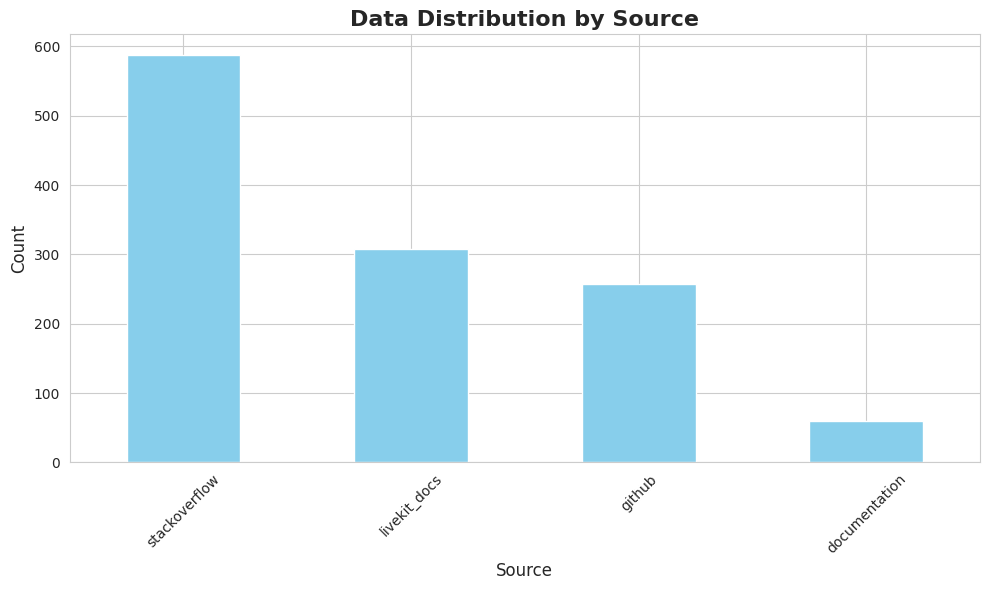


Samples per source:
source
stackoverflow    588
livekit_docs     308
github           258
documentation     60
Name: count, dtype: int64


In [20]:
# Distribution by source
source_counts = df['source'].value_counts()

plt.figure(figsize=(10, 6))
source_counts.plot(kind='bar', color='skyblue')
plt.title('Data Distribution by Source', fontsize=16, fontweight='bold')
plt.xlabel('Source', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nSamples per source:")
print(source_counts)

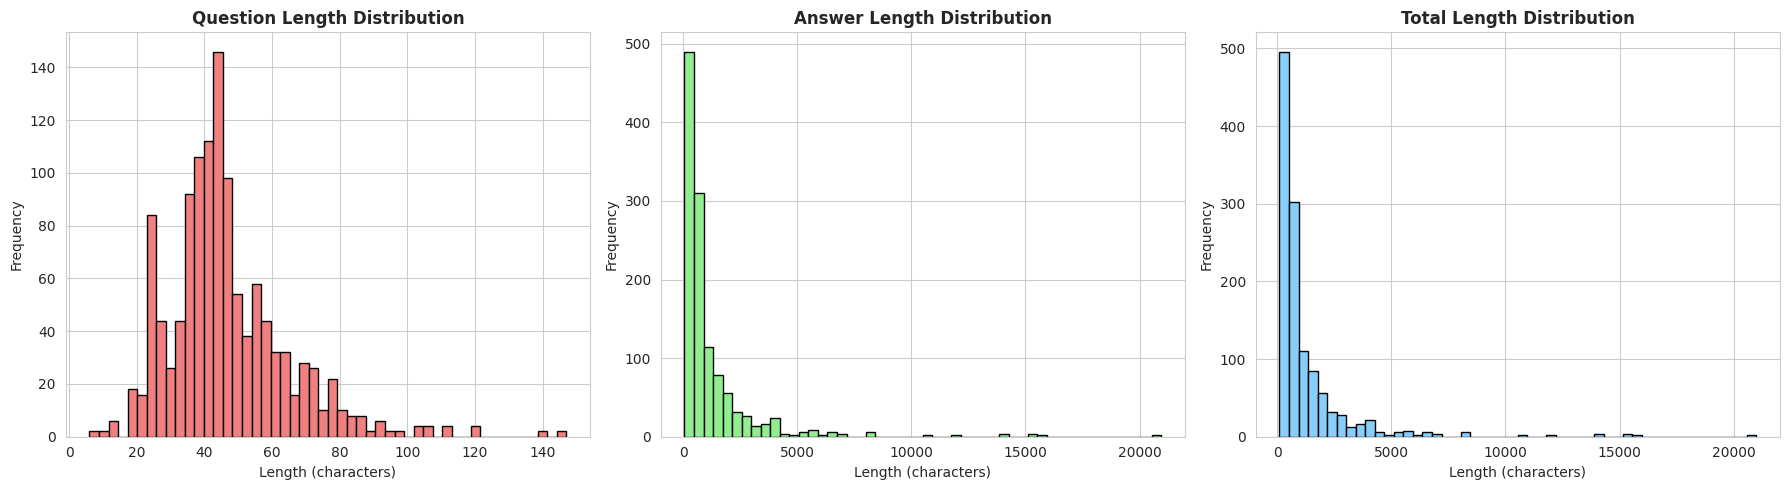

In [21]:
# Length distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['question_length'], bins=50, color='lightcoral', edgecolor='black')
axes[0].set_title('Question Length Distribution', fontweight='bold')
axes[0].set_xlabel('Length (characters)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['answer_length'], bins=50, color='lightgreen', edgecolor='black')
axes[1].set_title('Answer Length Distribution', fontweight='bold')
axes[1].set_xlabel('Length (characters)')
axes[1].set_ylabel('Frequency')

axes[2].hist(df['total_length'], bins=50, color='lightskyblue', edgecolor='black')
axes[2].set_title('Total Length Distribution', fontweight='bold')
axes[2].set_xlabel('Length (characters)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 4. Tag Analysis

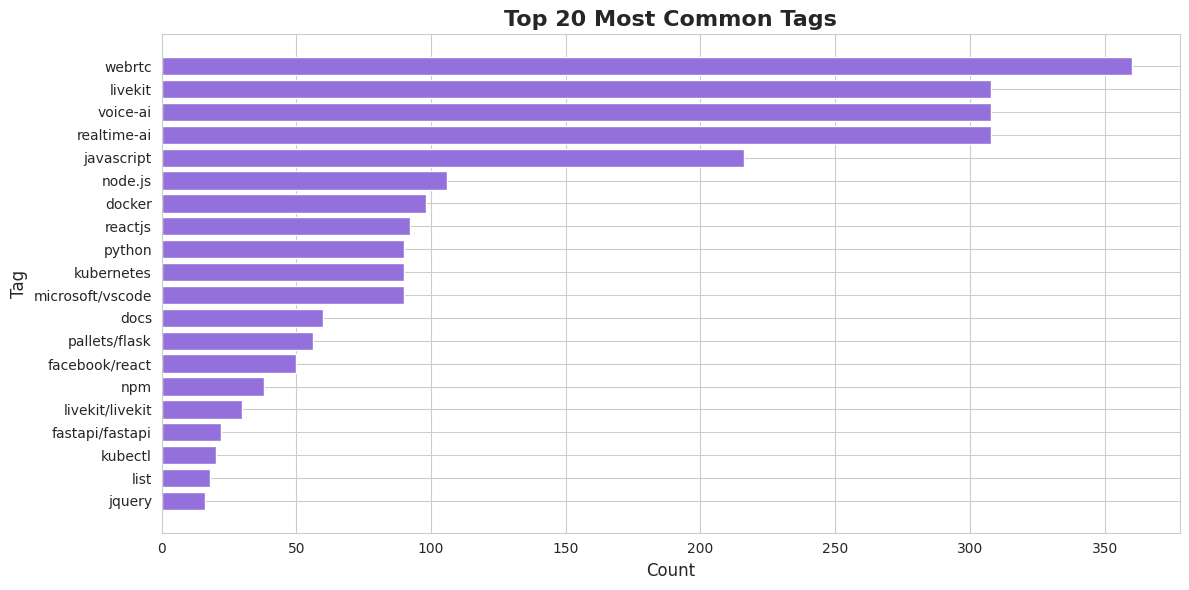


Total unique tags: 339
Top 10 tags: ['webrtc', 'livekit', 'voice-ai', 'realtime-ai', 'javascript', 'node.js', 'docker', 'reactjs', 'python', 'kubernetes']


In [22]:
# Extract all tags
all_tags = []
for tags in df['tags']:
    if isinstance(tags, list):
        all_tags.extend(tags)

tag_counts = Counter(all_tags)
top_tags = dict(tag_counts.most_common(20))

# Plot top tags
plt.figure(figsize=(12, 6))
plt.barh(list(top_tags.keys()), list(top_tags.values()), color='mediumpurple')
plt.title('Top 20 Most Common Tags', fontsize=16, fontweight='bold')
plt.xlabel('Count', fontsize=12)
plt.ylabel('Tag', fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nTotal unique tags: {len(tag_counts)}")
print(f"Top 10 tags: {list(top_tags.keys())[:10]}")

## 5. Quality Score Analysis

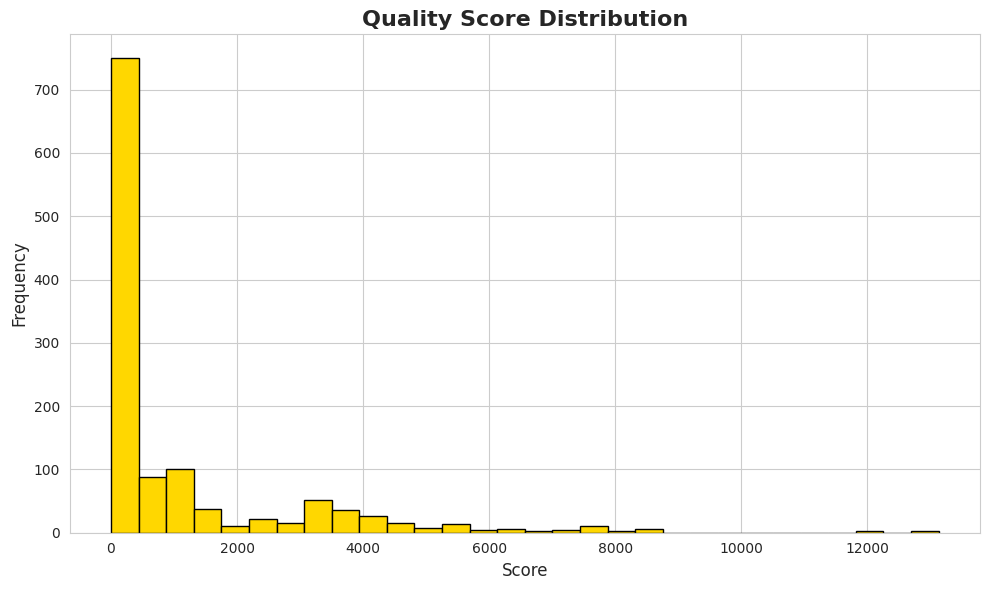


Score statistics:
count     1214.000000
mean      1071.088962
std       1842.897258
min          1.000000
25%          1.000000
50%        176.000000
75%       1135.000000
max      13134.000000
Name: score, dtype: float64


In [23]:
# Score distribution
plt.figure(figsize=(10, 6))
plt.hist(df['score'], bins=30, color='gold', edgecolor='black')
plt.title('Quality Score Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

print("\nScore statistics:")
print(df['score'].describe())

## 6. Sample Data Inspection

In [24]:
# Display random samples
print("Random Sample 1:")
print("="*80)
sample = df.sample(1).iloc[0]
print(f"Source: {sample['source']}")
print(f"Tags: {sample['tags']}")
print(f"Score: {sample['score']}")
print(f"\nQuestion: {sample['question']}")
print(f"\nAnswer: {sample['answer'][:500]}...")  # First 500 chars

Random Sample 1:
Source: stackoverflow
Tags: ['docker']
Score: 844

Question: docker push error: denied: requested access to the resource is denied

Answer: Thanks to the responses provided by others ( Dean Wu's , ses' , and Hito's ), before pushing, remember to log out , then log in from the command line to your docker hub account: docker login According to the Docker documentation : You need to include the namespace for Docker Hub to associate it with your account. The namespace is the same as your Docker Hub account name. You need to rename the image to YOUR_DOCKERHUB_NAME/docker-whale. So, this means you have to tag your image before pushing: do...


## 7. Data Quality Assessment

In [25]:
# Quality checks
print("Data Quality Checks:")
print("="*80)

# Empty questions or answers
empty_questions = df['question'].str.strip().eq('').sum()
empty_answers = df['answer'].str.strip().eq('').sum()
print(f"Empty questions: {empty_questions}")
print(f"Empty answers: {empty_answers}")

# Very short entries
short_questions = (df['question_length'] < 20).sum()
short_answers = (df['answer_length'] < 50).sum()
print(f"\nVery short questions (<20 chars): {short_questions}")
print(f"Very short answers (<50 chars): {short_answers}")

# Very long entries
long_questions = (df['question_length'] > 1000).sum()
long_answers = (df['answer_length'] > 2000).sum()
print(f"\nVery long questions (>1000 chars): {long_questions}")
print(f"Very long answers (>2000 chars): {long_answers}")

# Duplicates
duplicate_questions = df['question'].duplicated().sum()
print(f"\nDuplicate questions: {duplicate_questions}")

Data Quality Checks:
Empty questions: 0
Empty answers: 0

Very short questions (<20 chars): 20
Very short answers (<50 chars): 0

Very long questions (>1000 chars): 0
Very long answers (>2000 chars): 176

Duplicate questions: 783


## 8. Recommendations

In [26]:
print("\n" + "="*80)
print("RECOMMENDATIONS FOR DATA PREPROCESSING")
print("="*80)

recommendations = []

if empty_questions > 0 or empty_answers > 0:
    recommendations.append("❌ Remove entries with empty questions or answers")

if short_questions > 0 or short_answers > 0:
    recommendations.append("❌ Filter out very short questions/answers")

if duplicate_questions > 0:
    recommendations.append("❌ Remove duplicate questions")

if long_answers > 100:
    recommendations.append("⚠️  Consider truncating very long answers")

recommendations.append("✅ Apply text normalization (lowercase, remove extra spaces)")
recommendations.append("✅ Split data into train/validation/test (80/10/10)")
recommendations.append("✅ Balance tag distribution if heavily skewed")

for i, rec in enumerate(recommendations, 1):
    print(f"{i}. {rec}")

print("\n" + "="*80)
print(f"Expected clean dataset size: ~{len(df) - empty_questions - empty_answers - duplicate_questions} samples")
print("="*80)


RECOMMENDATIONS FOR DATA PREPROCESSING
1. ❌ Filter out very short questions/answers
2. ❌ Remove duplicate questions
3. ⚠️  Consider truncating very long answers
4. ✅ Apply text normalization (lowercase, remove extra spaces)
5. ✅ Split data into train/validation/test (80/10/10)
6. ✅ Balance tag distribution if heavily skewed

Expected clean dataset size: ~431 samples


## Conclusion

This exploratory analysis provides insights into:
- Dataset size and composition
- Text length distributions
- Tag/topic coverage
- Data quality issues

**Next Steps**:
1. Run `data_preprocessing.py` to clean and format the data
2. Proceed to model fine-tuning notebook
3. Evaluate model performance